In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

C:\Users\fpatrick\AppData\Local\Temp\ipykernel_4592\2535116935.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


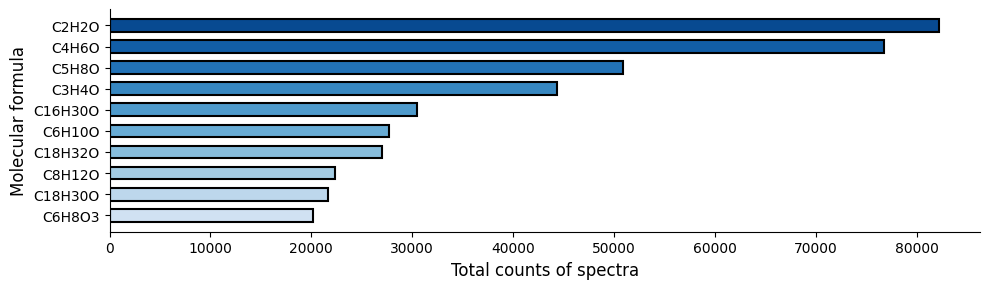

In [14]:
# 1) Load CSV
CSV_FILE = 'carnitines_final_table_only_CHO.tsv'
try:
    df = pd.read_csv(CSV_FILE, sep="\t")
except FileNotFoundError:
    print(f"ERROR: The file '{CSV_FILE}' was not found. Please check the path and filename.")
    raise SystemExit

# 2) Group, sum, and take Top 10
df['counts'] = pd.to_numeric(df['counts'], errors='coerce')
top_10_data = (
    df.groupby('delta_MF_final')['counts']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# 3) Color gradient
num_bars = len(top_10_data)
cmap = cm.get_cmap('Blues')
colors = [cmap(0.9 - 0.7 * i / (num_bars - 1)) for i in range(num_bars)]

# 4) Horizontal plot
plt.figure(figsize=(10, 3))
ax = plt.gca()

bars = ax.barh(
    y=top_10_data.index,
    width=top_10_data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    height=0.6
)

# 5) Style and axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Total counts of spectra', fontsize=12)
ax.set_ylabel('Molecular formula', fontsize=12)

# Put the largest at the top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('Figure 1f.pdf')
plt.show()


C:\Users\fpatrick\AppData\Local\Temp\ipykernel_4592\3486708084.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Purples')


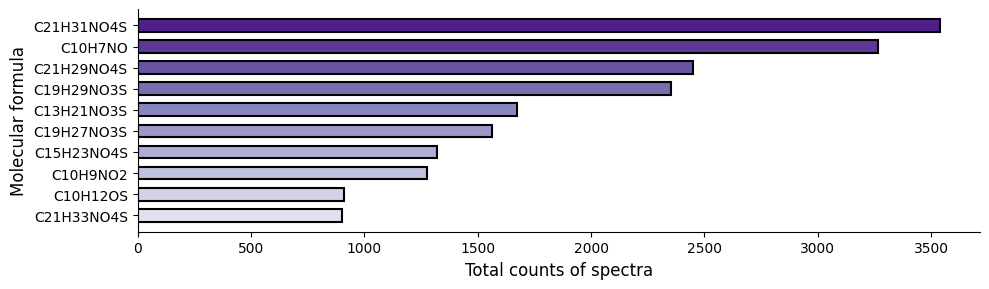

In [15]:
# 1) Load CSV
CSV_FILE = 'carnitines_final_table_diff_CHO.tsv'
try:
    df = pd.read_csv(CSV_FILE, sep="\t")
except FileNotFoundError:
    print(f"ERROR: The file '{CSV_FILE}' was not found. Please check the path and filename.")
    raise SystemExit

# 2) Group, sum, and take Top 10
df['counts'] = pd.to_numeric(df['counts'], errors='coerce')
top_10_data = (
    df.groupby('delta_MF_final')['counts']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# 3) Color gradient
num_bars = len(top_10_data)
cmap = cm.get_cmap('Purples')
colors = [cmap(0.9 - 0.7 * i / (num_bars - 1)) for i in range(num_bars)]

# 4) Horizontal plot
plt.figure(figsize=(10, 3))
ax = plt.gca()

bars = ax.barh(
    y=top_10_data.index,
    width=top_10_data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    height=0.6
)

# 5) Style and axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Total counts of spectra', fontsize=12)
ax.set_ylabel('Molecular formula', fontsize=12)

# Put the largest at the top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('Figure 1g.pdf')
plt.show()
